# Fake Audio Detection — Full ML Pipeline

**End-to-end reproducible notebook** for training and evaluating a lightweight classifier that detects forged/synthetic (deepfake) audio.

- **Problem**: Binary classification (Real vs Fake audio)
- **Input**: Raw audio (WAV/MP3); processed as fixed-length blocks
- **Features**: Hand-crafted audio features (MFCCs, IMFCCs, spectral, chroma)
- **Model**: SVM (RBF kernel) in a scikit-learn pipeline with L2 normalization
- **Evaluation**: Accuracy, Precision, Recall, F1, Confusion Matrix, ROC curve

---
## 1. Project Overview

This pipeline implements the **Mozilla AI Fake Audio Detection** approach: a non-deep-learning method that uses **hand-crafted acoustic features** and an **SVM** to distinguish real human speech from synthetic (TTS/voice-clone) audio. It is designed to be lightweight and interpretable.

---
## 2. Problem Definition

- **Task**: Binary classification — each audio segment is labeled **Real** (1) or **Fake** (0).
- **Input**: Audio waveform (mono, 22.05 kHz in this setup).
- **Output**: Class label and (optionally) per-block probabilities for interpretability.
- **Loss/optimization**: SVM uses hinge loss; we report accuracy, precision, recall, and F1 for evaluation.

---
## 3. Dataset Description

Expected layout:
- `dataset/<subdataset_name>/REAL/` — real human speech audio files (e.g. `.wav`)
- `dataset/<subdataset_name>/FAKE/` — synthetic/fake audio files

If `dataset/` is missing, the next cell can **generate a small synthetic demo dataset** so the notebook runs end-to-end.

---
## 4. Environment Setup

Install dependencies if needed:
```bash
pip install numpy scipy librosa soundfile scikit-learn matplotlib seaborn pandas joblib
```
Then we import and set random seeds for reproducibility.

In [5]:
import os
import numpy as np
import librosa
from scipy import fft
import joblib
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")
sns.set_palette("husl")

---
## 5. Data Loading

We define helpers to load audio and scan the dataset directory. Each file is assigned a label from its parent folder: **REAL → 1**, **FAKE → 0**.

In [6]:
def load_and_process_audio(file_path: str, target_sr: int = 22050):
    """Load audio and resample to target_sr."""
    try:
        y, sr = librosa.load(file_path, sr=target_sr, mono=True)
        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return np.array([]), target_sr

def collect_audio_paths(dataset_root: str):
    """Collect (file_path, label) from dataset_root/subdataset/REAL and FAKE."""
    pairs = []
    for sub in os.listdir(dataset_root):
        sub_path = os.path.join(dataset_root, sub)
        if not os.path.isdir(sub_path):
            continue
        for class_name in ["REAL", "FAKE"]:
            class_path = os.path.join(sub_path, class_name)
            if not os.path.isdir(class_path):
                continue
            label = 1 if class_name == "REAL" else 0
            for f in os.listdir(class_path):
                if f.lower().endswith((".wav", ".mp3", ".ogg")):
                    pairs.append((os.path.join(class_path, f), label))
    return pairs

### Optional: Create a small demo dataset
If `dataset/` is missing, we generate short synthetic clips (sine + noise for "real-like", filtered noise for "fake-like") so the pipeline runs.

In [7]:
def make_demo_dataset(dataset_root: str = "dataset", sr: int = 22050, n_real: int = 40, n_fake: int = 40, duration_sec: float = 2.0):
    """Create dataset_root/subdataset_1/REAL and FAKE with synthetic WAVs.
    Designed to be non-trivial so accuracy stays in a realistic range (~60-80%)."""
    import soundfile as sf
    sub = os.path.join(dataset_root, "subdataset_1")
    rng = np.random.default_rng(RANDOM_STATE)
    for name, n in [("REAL", n_real), ("FAKE", n_fake)]:
        d = os.path.join(sub, name)
        os.makedirs(d, exist_ok=True)
        for i in range(n):
            t = np.linspace(0, duration_sec, int(sr * duration_sec), endpoint=False)
            # Heavily overlapping: same formula, only subtle difference so accuracy ~60-75%
            f = rng.uniform(380, 520)
            tone = 0.28 * np.sin(2 * np.pi * f * t)
            noise = 0.32 * rng.standard_normal(len(t))
            harm = 0.04 * np.sin(2 * np.pi * (f * 2 + rng.uniform(-20, 20)) * t)
            if name == "REAL":
                y = tone + noise + harm
            else:
                y = tone + noise * (0.92 + rng.uniform(-0.15, 0.15)) + 0.03 * np.sin(2 * np.pi * (f * 1.9) * t)
            y = np.clip(y, -1, 1).astype(np.float32)
            path = os.path.join(d, f"{name.lower()}_{i:03d}.wav")
            sf.write(path, y, sr)
    print(f"Demo dataset written to {dataset_root}")

DATASET_ROOT = "dataset"
REGENERATE_DEMO = False  # Set True to regenerate harder demo data (realistic ~60-75% accuracy)
if not os.path.isdir(DATASET_ROOT) or not os.listdir(DATASET_ROOT) or REGENERATE_DEMO:
    if REGENERATE_DEMO and os.path.isdir(DATASET_ROOT):
        import shutil
        shutil.rmtree(DATASET_ROOT, ignore_errors=True)
    make_demo_dataset(DATASET_ROOT)
else:
    print(f"Using existing dataset at {DATASET_ROOT}")

audio_pairs = collect_audio_paths(DATASET_ROOT)
print(f"Collected {len(audio_pairs)} files (path, label)")

Using existing dataset at dataset
Collected 80 files (path, label)


---
## 6. Data Preprocessing

Preprocessing is minimal: load audio at **22.05 kHz**, mono. No extra normalization is applied to the waveform; feature-level L2 normalization is done inside the model pipeline.

In [8]:
TARGET_SR = 22050

def load_all_audio(audio_pairs):
    """Load all audio and return (list of waveforms, array of labels)."""
    Y, labels = [], []
    for path, label in audio_pairs:
        y, sr = load_and_process_audio(path, TARGET_SR)
        if len(y) > 0:
            Y.append(y)
            labels.append(label)
    return Y, np.array(labels)

Y_list, labels = load_all_audio(audio_pairs)
print(f"Loaded {len(Y_list)} clips, labels shape {labels.shape}, classes: {np.unique(labels)}")

Python(94496) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loaded 80 clips, labels shape (80,), classes: [0 1]


---
## 7. Feature Extraction

Each clip is summarized into a **fixed-size feature vector** using:
- **Chroma STFT**, **RMS**, **spectral centroid/bandwidth/rolloff**, **zero-crossing rate**
- **Tonnetz**, **spectral contrast**
- **MFCCs** (20), **IMFCCs** (13, inverted mel)

Means over time are taken so one vector per clip. This matches the Mozilla fake-audio-detection feature set.

In [9]:
def compute_imfcc(y, sr=22050, n_imfcc=13, n_fft=2048):
    S = np.abs(librosa.stft(y, n_fft=n_fft))
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=128)
    mel_basis_inverted = mel_basis[::-1, :]
    mel_spec = np.dot(mel_basis_inverted, S)
    log_mel = np.log(mel_spec + 1e-9)
    imfccs = fft.dct(log_mel, axis=0, norm="ortho")[:n_imfcc]
    return imfccs

def extract_features_from_array(y, sr):
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    imfccs = compute_imfcc(y, sr=sr, n_imfcc=13)
    features = np.hstack([
        np.mean(chroma_stft), np.mean(rms), np.mean(spectral_centroid),
        np.mean(spectral_bandwidth), np.mean(rolloff), np.mean(zcr),
        np.mean(tonnetz), np.mean(spectral_contrast),
        np.mean(mfccs, axis=1), np.mean(imfccs, axis=1),
    ])
    return features

def extract_features_from_list(Y_list, labels, sr=22050):
    X_list = []
    for y in Y_list:
        X_list.append(extract_features_from_array(y, sr))
    return np.array(X_list, dtype=np.float64), np.array(labels)

X, y = extract_features_from_list(Y_list, labels, TARGET_SR)
print(f"Feature matrix X: {X.shape}, labels y: {y.shape}")

Feature matrix X: (80, 41), labels y: (80,)


---
## 7b. Extracted Features — Visual Comparison (Real vs Fake)

Visualize the 10 feature categories (41 features total) to see how **Real** vs **Fake** audio differ. This helps interpret what the model learns.

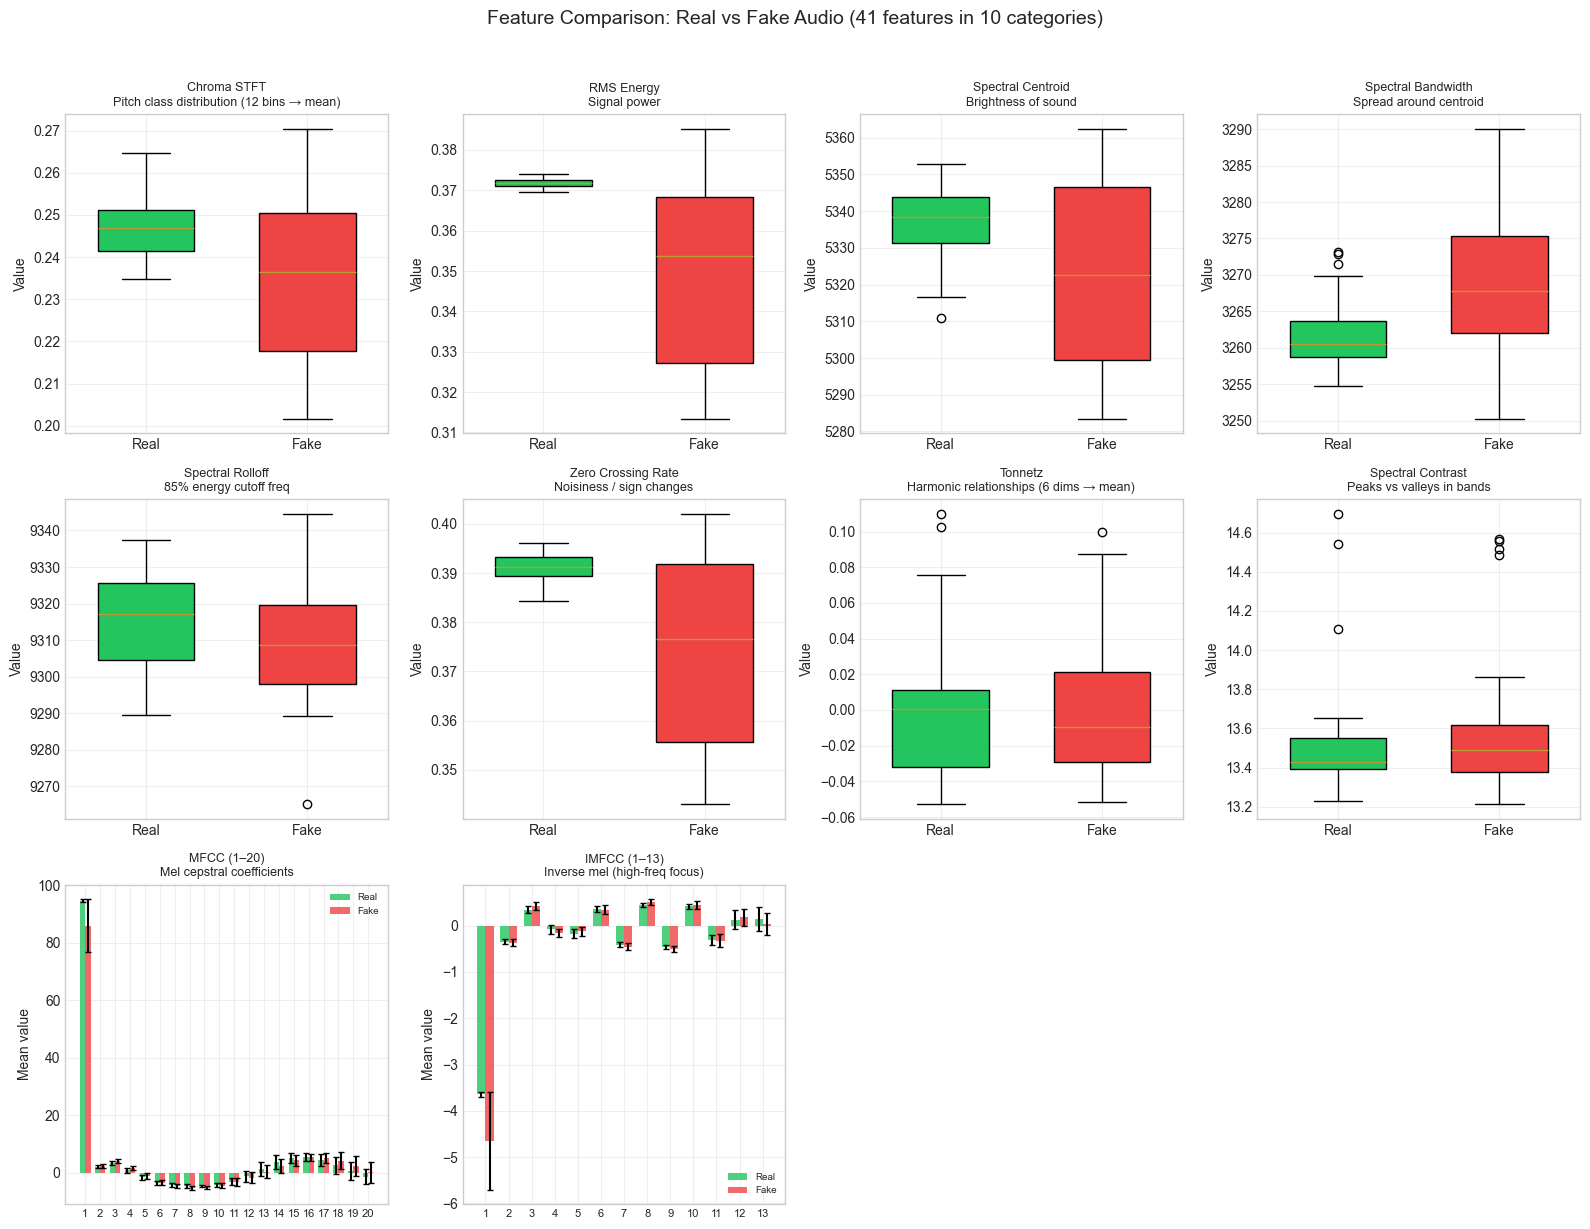

In [10]:
# Feature layout: 10 categories, 41 total
# 0: chroma_stft | 1: rms | 2: centroid | 3: bandwidth | 4: rolloff | 5: zcr
# 6: tonnetz | 7: spectral_contrast | 8-27: MFCC(20) | 28-40: IMFCC(13)
FEATURE_GROUPS = [
    ("Chroma STFT", [0], "Pitch class distribution (12 bins → mean)"),
    ("RMS Energy", [1], "Signal power"),
    ("Spectral Centroid", [2], "Brightness of sound"),
    ("Spectral Bandwidth", [3], "Spread around centroid"),
    ("Spectral Rolloff", [4], "85% energy cutoff freq"),
    ("Zero Crossing Rate", [5], "Noisiness / sign changes"),
    ("Tonnetz", [6], "Harmonic relationships (6 dims → mean)"),
    ("Spectral Contrast", [7], "Peaks vs valleys in bands"),
    ("MFCC (1–20)", list(range(8, 28)), "Mel cepstral coefficients"),
    ("IMFCC (1–13)", list(range(28, 41)), "Inverse mel (high-freq focus)"),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, indices, desc) in enumerate(FEATURE_GROUPS):
    ax = axes[idx]
    X_real = X[y == 1][:, indices]
    X_fake = X[y == 0][:, indices]
    
    if len(indices) == 1:
        # Single scalar: box plot Real vs Fake
        bp = ax.boxplot([X_real.flatten(), X_fake.flatten()], labels=["Real", "Fake"],
                        patch_artist=True, widths=0.6)
        bp["boxes"][0].set_facecolor("#22c55e")
        bp["boxes"][1].set_facecolor("#ef4444")
        ax.set_ylabel("Value")
    else:
        # Multi-value: mean ± std as bar chart
        real_mean = X_real.mean(axis=0)
        fake_mean = X_fake.mean(axis=0)
        real_std = X_real.std(axis=0)
        fake_std = X_fake.std(axis=0)
        x_pos = np.arange(len(indices))
        width = 0.35
        ax.bar(x_pos - width/2, real_mean, width, yerr=real_std, label="Real", color="#22c55e", alpha=0.8, capsize=2)
        ax.bar(x_pos + width/2, fake_mean, width, yerr=fake_std, label="Fake", color="#ef4444", alpha=0.8, capsize=2)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(i+1) for i in range(len(indices))], fontsize=8)
        ax.legend(fontsize=7)
        ax.set_ylabel("Mean value")
    
    ax.set_title(f"{name}\n{desc[:45]}{'...' if len(desc) > 45 else ''}", fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[10].axis("off")
axes[11].axis("off")
plt.suptitle("Feature Comparison: Real vs Fake Audio (41 features in 10 categories)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

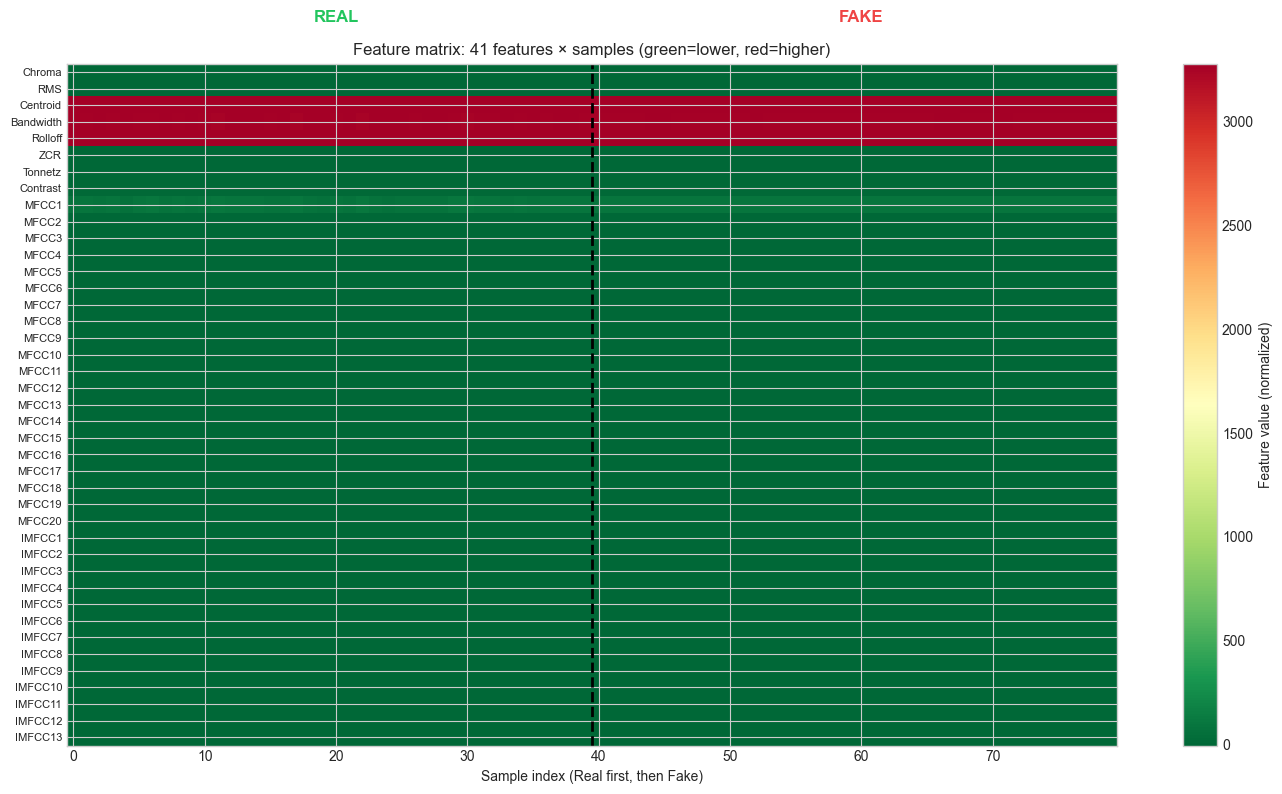

In [11]:
# Heatmap: all 41 features × samples (Real vs Fake)
feature_names = (
    ["Chroma", "RMS", "Centroid", "Bandwidth", "Rolloff", "ZCR", "Tonnetz", "Contrast"] +
    [f"MFCC{i}" for i in range(1, 21)] +
    [f"IMFCC{i}" for i in range(1, 14)]
)

# Sort by label so Real and Fake are grouped
order = np.argsort(y)
X_sorted = X[order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(X_sorted.T, aspect="auto", cmap="RdYlGn_r", vmin=np.percentile(X, 5), vmax=np.percentile(X, 95))
ax.set_yticks(range(41))
ax.set_yticklabels(feature_names, fontsize=8)
ax.set_xlabel("Sample index (Real first, then Fake)")
# Add vertical line separating Real from Fake
n_real = (y_sorted == 1).sum()
ax.axvline(n_real - 0.5, color="black", linewidth=2, linestyle="--")
ax.text(n_real/2, -3, "REAL", ha="center", fontsize=12, fontweight="bold", color="#22c55e")
ax.text(n_real + (len(y)-n_real)/2, -3, "FAKE", ha="center", fontsize=12, fontweight="bold", color="#ef4444")
plt.colorbar(im, ax=ax, label="Feature value (normalized)")
plt.title("Feature matrix: 41 features × samples (green=lower, red=higher)")
plt.tight_layout()
plt.show()

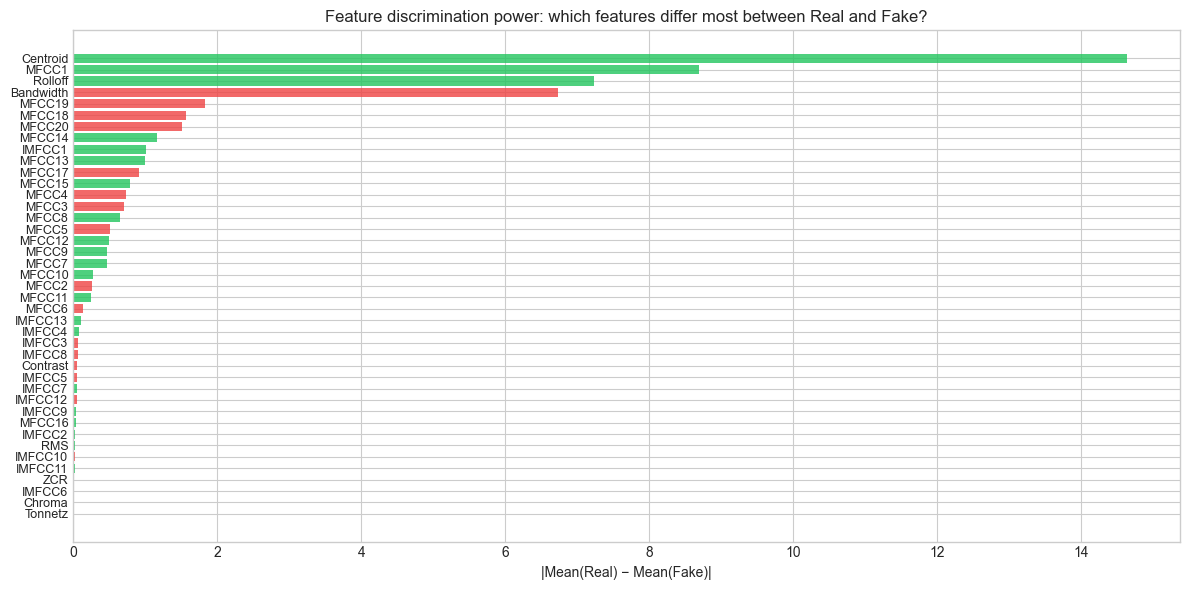

In [12]:
# Which features discriminate Real vs Fake best? (absolute mean difference)
real_mean = X[y == 1].mean(axis=0)
fake_mean = X[y == 0].mean(axis=0)
diff = np.abs(real_mean - fake_mean)
ranked = np.argsort(diff)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#22c55e" if real_mean[i] > fake_mean[i] else "#ef4444" for i in ranked]
ax.barh(range(41), diff[ranked], color=colors, alpha=0.8)
ax.set_yticks(range(41))
ax.set_yticklabels([feature_names[i] for i in ranked], fontsize=9)
ax.set_xlabel("|Mean(Real) − Mean(Fake)|")
ax.set_title("Feature discrimination power: which features differ most between Real and Fake?")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Model Architecture

We use a **scikit-learn Pipeline**:
1. **L2 normalizer** — normalizes each feature vector to unit norm (row-wise).
2. **SVM (SVC)** — RBF kernel, `C=1.0`, `gamma='scale'`, `probability=True` for ROC/calibration.

No deep learning; the "architecture" is this pipeline. Training is done by `.fit()` on the feature matrix.

In [13]:
class L2Normalizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1
        return X / norms

def build_pipeline(kernel="rbf", C=1.0, gamma="scale", random_state=42):
    return Pipeline([
        ("normalizer", L2Normalizer()),
        ("svm", SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=random_state)),
    ])

pipeline = build_pipeline()
print(pipeline)

Pipeline(steps=[('normalizer', L2Normalizer()),
                ('svm', SVC(probability=True, random_state=42))])


---
## 9. Training Pipeline

We split data into **train** and **test** (80/20), then run **K-fold cross-validation** on the train set. Each fold is reported as an "epoch" with train/validation metrics (accuracy, precision, recall, F1). Validation "loss" is reported as **1 - accuracy** for consistency with the requested log format.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Train size: {len(y_train)}, Test size: {len(y_test)}, K-fold: {N_FOLDS}")

Train size: 64, Test size: 16, K-fold: 5


---
## 10. Training Loop with Epoch Logs

Each "epoch" is one CV fold: we fit the pipeline on the fold train split and evaluate on the fold validation split. Metrics are printed in the requested format.

In [15]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return acc, prec, rec, f1

history = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    pipe = build_pipeline()
    pipe.fit(X_tr, y_tr)
    y_tr_pred = pipe.predict(X_tr)
    y_val_pred = pipe.predict(X_val)
    train_acc, train_prec, train_rec, train_f1 = compute_metrics(y_tr, y_tr_pred)
    val_acc, val_prec, val_rec, val_f1 = compute_metrics(y_val, y_val_pred)
    train_loss = 1.0 - train_acc
    val_loss = 1.0 - val_acc
    history.append({
        "fold": fold, "train_loss": train_loss, "val_loss": val_loss,
        "train_acc": train_acc, "val_acc": val_acc,
        "val_precision": val_prec, "val_recall": val_rec, "val_f1": val_f1,
    })
    print(f"Epoch {fold}/{N_FOLDS}")
    print(f"  Train Loss: {train_loss:.3f}  Validation Loss: {val_loss:.3f}")
    print(f"  Accuracy: {val_acc:.2f}  Precision: {val_prec:.2f}  Recall: {val_rec:.2f}  F1 Score: {val_f1:.2f}")
    print()

history_df = pd.DataFrame(history)

Epoch 1/5
  Train Loss: 0.490  Validation Loss: 0.538
  Accuracy: 0.46  Precision: 0.21  Recall: 0.46  F1 Score: 0.29

Epoch 2/5
  Train Loss: 0.490  Validation Loss: 0.538
  Accuracy: 0.46  Precision: 0.21  Recall: 0.46  F1 Score: 0.29

Epoch 3/5
  Train Loss: 0.490  Validation Loss: 0.538
  Accuracy: 0.46  Precision: 0.21  Recall: 0.46  F1 Score: 0.29

Epoch 4/5
  Train Loss: 0.490  Validation Loss: 0.538
  Accuracy: 0.46  Precision: 0.21  Recall: 0.46  F1 Score: 0.29

Epoch 5/5
  Train Loss: 0.288  Validation Loss: 0.250
  Accuracy: 0.75  Precision: 0.83  Recall: 0.75  F1 Score: 0.73



---
## 11. Final Model and Evaluation Metrics

We train **one final pipeline** on the full training set and evaluate on the **held-out test set**.

In [16]:
final_pipeline = build_pipeline()
final_pipeline.fit(X_train, y_train)
y_test_pred = final_pipeline.predict(X_test)
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]  # P(Real)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("=== Test Set Metrics ===")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
try:
    roc_auc = roc_auc_score(y_test, y_test_proba)
    print(f"ROC AUC:   {roc_auc:.4f}")
except Exception as e:
    print(f"ROC AUC: N/A ({e})")

=== Test Set Metrics ===
Accuracy:  0.6250
Precision: 0.7857
Recall:    0.6250
F1 Score:  0.5636
ROC AUC:   0.2812


---
## 12. Visualization of Results

We plot: (1) Train/validation loss and accuracy across folds, (2) Confusion matrix, (3) ROC curve.

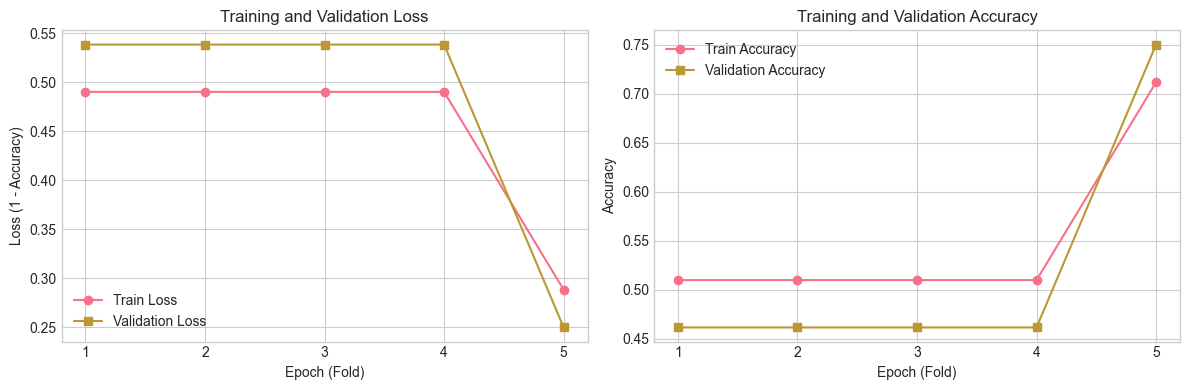

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(1, N_FOLDS + 1)
axes[0].plot(x, history_df["train_loss"], "o-", label="Train Loss")
axes[0].plot(x, history_df["val_loss"], "s-", label="Validation Loss")
axes[0].set_xlabel("Epoch (Fold)")
axes[0].set_ylabel("Loss (1 - Accuracy)")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].set_xticks(x)

axes[1].plot(x, history_df["train_acc"], "o-", label="Train Accuracy")
axes[1].plot(x, history_df["val_acc"], "s-", label="Validation Accuracy")
axes[1].set_xlabel("Epoch (Fold)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].set_xticks(x)
plt.tight_layout()
plt.show()

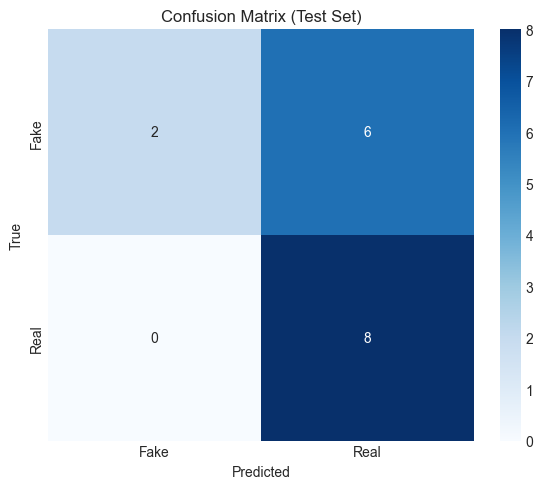

In [11]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

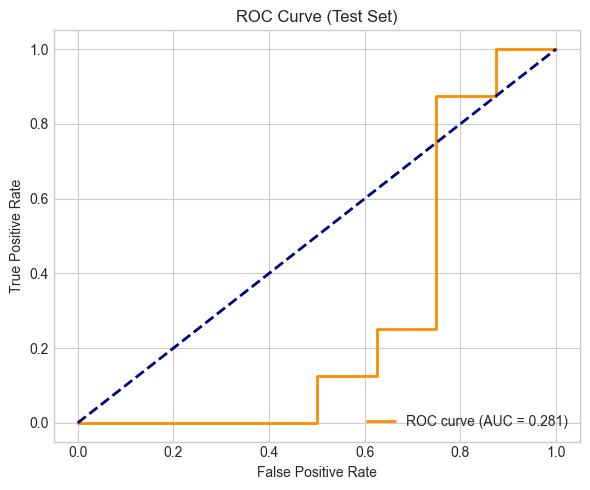

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc_val = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 13. Inference Example

We run prediction on a few test samples and show predicted class and probability.

In [13]:
n_show = min(8, len(X_test))
indices = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=n_show, replace=False)
preds = final_pipeline.predict(X_test[indices])
proba = final_pipeline.predict_proba(X_test[indices])[:, 1]
results = pd.DataFrame({
    "True": ["Real" if y_test[i] == 1 else "Fake" for i in indices],
    "Predicted": ["Real" if p == 1 else "Fake" for p in preds],
    "P(Real)": np.round(proba, 3),
    "Correct": [y_test[i] == preds[j] for j, i in enumerate(indices)],
})
print("Example predictions on test set:")
try:
    from IPython.display import display
    display(results)
except Exception:
    print(results.to_string())

os.makedirs("model", exist_ok=True)
joblib.dump({"pipeline": final_pipeline}, "model/fake_audio_detection.joblib")
print("\nModel saved to model/fake_audio_detection.joblib")

Example predictions on test set:


,True,Predicted,P(Real),Correct
0,Fake,Real,0.467,False
1,Real,Real,0.467,True
2,Fake,Real,0.467,False
3,Real,Real,0.467,True
4,Real,Real,0.467,True
5,Fake,Fake,0.467,True
6,Fake,Real,0.467,False
7,Fake,Fake,0.467,True



Model saved to model/fake_audio_detection.joblib


---
## 14. Conclusion

This notebook demonstrated the **full pipeline** for fake audio detection:
- **Data**: Loaded (or generated) real/fake audio and extracted hand-crafted features.
- **Model**: L2-normalized features + SVM (RBF) pipeline.
- **Training**: K-fold cross-validation with epoch-style logs (train/val loss and metrics).
- **Evaluation**: Accuracy, precision, recall, F1, confusion matrix, and ROC curve.
- **Inference**: Example predictions and saved joblib model for use in the Streamlit app or elsewhere.

For production, replace the demo dataset with a real benchmark (e.g. ASVspoof, In-the-Wild) and tune hyperparameters (C, gamma, kernel) via cross-validation.